# Neural Tokenizers vs BPE and WordPiece on AG News

This notebook implements a neural network-based tokenizer and compares it with two traditional tokenization approaches: **Byte-Pair Encoding (BPE)** and **WordPiece**.

The neural tokenizer is formulated as a **character-level boundary prediction model**:
- input: a word as a sequence of characters
- output: a binary boundary vector of the same length
- value `1` means that a token boundary occurs **after** this character
- value `0` means no boundary after this character

Example:

`tokenizator -> [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

This means there is a split after the 5th character:
- `token | izator`

The notebook uses:
- **AG News** as the dataset
- **Hugging Face Tokenizers** for BPE and WordPiece
- **SentencePiece Unigram with sampling** to create pseudo-labels for token boundaries
- a **BiLSTM** neural model for boundary prediction
- a small **text classification experiment** to compare downstream performance

## 1. Setup

In [1]:
!pip install datasets tokenizers sentencepiece scikit-learn matplotlib pandas tqdm

import os
import re
import json
import math
import time
import random
import string
import tempfile
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from datasets import load_dataset

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, decoders
import sentencepiece as spm

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [63]:
MAX_TRAIN_TEXTS = 30000 
MAX_VAL_TEXTS   = 5000
MAX_TEST_TEXTS  = 5000

TOKENIZER_VOCAB_SIZE = 4000
SP_VOCAB_SIZE = 8000

CHAR_EMB_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.2

BATCH_SIZE_WORDS = 256
BATCH_SIZE_TEXTS = 128

NUM_EPOCHS_BOUNDARY = 10
NUM_EPOCHS_CLASSIFIER = 5

LR_BOUNDARY = 1e-3
LR_CLASSIFIER = 2e-3

MAX_WORD_TYPES_FOR_BOUNDARY_TRAIN = 40000
MIN_WORD_FREQ = 2

SAMPLING_ROUNDS = 50
SAMPLING_ALPHA = 0.3
SAMPLING_NBEST = -1
BOUNDARY_THRESHOLD = 0.5

CLS_EMBED_DIM = 128

SPECIAL_TOKENS = ["[PAD]", "[UNK]"]

## 2. Dataset

I use the AG News dataset, which is a standard text classification benchmark with four categories:

1. World
2. Sports
3. Business
4. Sci/Tech

This dataset is convenient because:
- it contains real news headlines and short descriptions
- it is large enough for tokenization experiments
- it supports a downstream classification task

In [64]:
dataset = load_dataset("ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [66]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [67]:
train_df = train_df.rename(columns={"label": "target"})
test_df = test_df.rename(columns={"label": "target"})

full_train_texts = train_df["text"].tolist()
full_train_labels = train_df["target"].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    full_train_texts,
    full_train_labels,
    test_size=MAX_VAL_TEXTS,
    random_state=SEED,
    stratify=full_train_labels
)

X_train = X_train[:MAX_TRAIN_TEXTS]
y_train = y_train[:MAX_TRAIN_TEXTS]

X_test = test_df["text"].tolist()[:MAX_TEST_TEXTS]
y_test = test_df["target"].tolist()[:MAX_TEST_TEXTS]

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 30000
Val:   5000
Test:  5000


In [68]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

pd.Series(y_train).value_counts().sort_index().rename(index=dict(enumerate(label_names)))

World       7402
Sports      7640
Business    7465
Sci/Tech    7493
Name: count, dtype: int64

In [69]:
def normalize_text(text: str) -> str:
    return text.lower().strip()

X_train_norm = [normalize_text(x) for x in X_train]
X_val_norm   = [normalize_text(x) for x in X_val]
X_test_norm  = [normalize_text(x) for x in X_test]

In [70]:
print(X_train_norm[0])
print("Label:", label_names[y_train[0]])

after wait, google set for market debut new york (reuters) - shares of google inc. will make their nasdaq stock market debut on thursday after the year #39;s most anticipated initial public offering priced far below initial estimates, raising \$1.67 billion.
Label: Business


## 3. Baseline tokenizers

I train two traditional subword tokenizers: BPE and WordPiece.

I train them on the AG News training texts and later compare them with the neural tokenizer.

In [71]:
all_train_chars = sorted(set("".join(X_train_norm)))

def train_hf_tokenizer(texts, algorithm: str, vocab_size: int = TOKENIZER_VOCAB_SIZE):
    if algorithm == "bpe":
        tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
        trainer = trainers.BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=SPECIAL_TOKENS,
            initial_alphabet=all_train_chars,
        )
        tokenizer.decoder = decoders.BPEDecoder()
    elif algorithm == "wordpiece":
        tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
        trainer = trainers.WordPieceTrainer(
            vocab_size=vocab_size,
            special_tokens=SPECIAL_TOKENS,
            initial_alphabet=all_train_chars,
        )
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    tokenizer.normalizer = normalizers.Sequence(
        [normalizers.NFKC(), normalizers.Lowercase()]
    )
    tokenizer.pre_tokenizer = pre_tokenizers.BertPreTokenizer()
    tokenizer.train_from_iterator(texts, trainer=trainer)
    return tokenizer

In [72]:
timings = {}

start = time.perf_counter()
bpe_tokenizer = train_hf_tokenizer(X_train_norm, algorithm="bpe", vocab_size=TOKENIZER_VOCAB_SIZE)
timings["bpe_train_time_sec"] = time.perf_counter() - start

start = time.perf_counter()
wp_tokenizer = train_hf_tokenizer(X_train_norm, algorithm="wordpiece", vocab_size=TOKENIZER_VOCAB_SIZE)
timings["wordpiece_train_time_sec"] = time.perf_counter() - start

timings

{'bpe_train_time_sec': 1.6393600979999974,
 'wordpiece_train_time_sec': 1.5475203280000187}

In [73]:
sample_sentence = X_train_norm[0]

print("Original:")
print(sample_sentence)

print("\nBPE:")
print(bpe_tokenizer.encode(sample_sentence).tokens)

print("\nWordPiece:")
print(wp_tokenizer.encode(sample_sentence).tokens)

Original:
after wait, google set for market debut new york (reuters) - shares of google inc. will make their nasdaq stock market debut on thursday after the year #39;s most anticipated initial public offering priced far below initial estimates, raising \$1.67 billion.

BPE:
['after', 'wait', ',', 'google', 'set', 'for', 'market', 'debut', 'new', 'york', '(', 'reuters', ')', '-', 'shares', 'of', 'google', 'inc', '.', 'will', 'make', 'their', 'nasdaq', 'stock', 'market', 'debut', 'on', 'thursday', 'after', 'the', 'year', '#', '39', ';', 's', 'most', 'anticip', 'ated', 'initial', 'public', 'offering', 'pr', 'ic', 'ed', 'far', 'below', 'initial', 'estimates', ',', 'raising', '\\', '$', '1', '.', '6', '7', 'billion', '.']

WordPiece:
['after', 'wait', ',', 'google', 'set', 'for', 'market', 'debut', 'new', 'york', '(', 'reuters', ')', '-', 'shares', 'of', 'google', 'inc', '.', 'will', 'make', 'their', 'nasdaq', 'stock', 'market', 'debut', 'on', 'thursday', 'after', 'the', 'year', '#', '39', 

In [74]:
def get_vocab_size_hf(tokenizer):
    return tokenizer.get_vocab_size()

print("BPE vocab size:", get_vocab_size_hf(bpe_tokenizer))
print("WordPiece vocab size:", get_vocab_size_hf(wp_tokenizer))

BPE vocab size: 4000
WordPiece vocab size: 4000


## 4. Neural tokenizer design

The neural tokenizer is implemented as a character-level sequence labeling model.

### Main idea
For each word, the model reads its characters and predicts a boundary label after every character.

### Example
For the word:

`tokenizator`

a possible boundary vector is:

`[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

This means:
- after `n` in `token`, a split is placed
- tokenization becomes `token | izator`

### Why BiLSTM?
A BiLSTM is used because:
- token boundaries depend on both left and right context inside the word
- character sequences are naturally sequential
- BiLSTM is simple and classical

### Model pipeline
1. map characters to embeddings
2. run a BiLSTM over the character sequence
3. project each hidden state to one logit
4. apply sigmoid to get boundary probability at each position

In [75]:
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def extract_words(text: str):
    return TOKEN_PATTERN.findall(text.lower().strip())

In [76]:
word_counter = Counter()
for text in X_train:
    word_counter.update(extract_words(text))

word_types = [word for word, freq in word_counter.items() if freq >= MIN_WORD_FREQ]
word_types = sorted(word_types, key=lambda w: (-word_counter[w], w))
word_types = word_types[:MAX_WORD_TYPES_FOR_BOUNDARY_TRAIN]
char2id = {"[PAD]": 0, "[UNK]": 1, **{ch: i + 2 for i, ch in enumerate(all_train_chars)}}
id2char = {i: ch for ch, i in char2id.items()}

print("Number of word types:", len(word_types))
print("Character vocab size:", len(char2id))

Number of word types: 25414
Character vocab size: 58


In [77]:
class BoundaryBiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.encoder = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.encoder(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        logits = self.classifier(out).squeeze(-1)
        return logits

## 5. Pseudo-label generation with SentencePiece Unigram + sampling

To train the neural tokenizer, we need boundary labels.

Instead of creating them by hand, I use SentencePiece Unigram as a teacher-like source of segmentation candidates.

### Why Unigram + sampling?
A deterministic segmentation gives only one answer. Sampling gives multiple possible segmentations, which is useful because:
- tokenization is often ambiguous
- some words can be segmented in more than one valid way
- repeated samples let us estimate which boundaries are stable

### Procedure
For each word:
1. sample several Unigram segmentations
2. convert each segmentation into a boundary vector
3. average the sampled vectors
4. convert the average into a hard binary boundary target

### Boundary convention
The boundary vector has the same length as the word.
- `1` means a split occurs **after** this character
- `0` means no split after this character
- the last position is usually `0`, because the end of the word is not treated as an internal boundary

Example:

`tokenizator -> [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

In [78]:
sp_dir = tempfile.mkdtemp()
sp_input_path = os.path.join(sp_dir, "ag_news_train.txt")
sp_model_prefix = os.path.join(sp_dir, "sp_unigram")

with open(sp_input_path, "w", encoding="utf-8") as f:
    for text in X_train_norm:
        f.write(text + "\n")

spm.SentencePieceTrainer.train(
    input=sp_input_path,
    model_prefix=sp_model_prefix,
    vocab_size=SP_VOCAB_SIZE,
    model_type="unigram",
    character_coverage=1.0,
    bos_id=-1,
    eos_id=-1,
    pad_id=-1,
    unk_id=0,
    input_sentence_size=200000,
    shuffle_input_sentence=True,
)

sp_unigram = spm.SentencePieceProcessor(model_file=sp_model_prefix + ".model")
print("SentencePiece Unigram model loaded.")

SentencePiece Unigram model loaded.


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmp_712uesr/ag_news_train.txt
  input_format: 
  model_prefix: /tmp/tmp_712uesr/sp_unigram
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 200000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: -1
  eos_id: -1
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  

In [79]:
def clean_sp_piece(piece: str) -> str:
    return piece.replace("▁", "")

def pieces_to_boundary_vector(word: str, pieces):
    """
    Convert a list of pieces into a binary boundary vector of length len(word).
    A value 1 means a split occurs AFTER that character.
    Example:
        word='tokenizator'
        pieces=['token', 'izator']
        -> [0,0,0,0,1,0,0,0,0,0,0]
    """
    word = word.lower()
    pieces = [clean_sp_piece(p) for p in pieces if clean_sp_piece(p) != ""]

    if "".join(pieces) != word:
        return [0] * len(word)

    boundary = [0] * len(word)
    cursor = 0

    for piece in pieces[:-1]:
        cursor += len(piece)
        if 0 < cursor < len(word):
            boundary[cursor - 1] = 1

    return boundary

In [80]:
example_word = "tokenizator"
example_pieces = ["token", "izator"]
example_boundary = pieces_to_boundary_vector(example_word, example_pieces)

print("Word:", example_word)
print("Pieces:", example_pieces)
print("Boundary:", example_boundary)

Word: tokenizator
Pieces: ['token', 'izator']
Boundary: [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]


In [81]:
def sample_sp_pieces(word, sp_model, alpha=SAMPLING_ALPHA, nbest_size=SAMPLING_NBEST):
    return sp_model.encode(
        word,
        out_type=str,
        enable_sampling=True,
        alpha=alpha,
        nbest_size=nbest_size,
    )

def estimate_boundary_probs(word, sp_model, rounds=SAMPLING_ROUNDS):
    samples = []
    for _ in range(rounds):
        pieces = sample_sp_pieces(word, sp_model)
        boundary = pieces_to_boundary_vector(word, pieces)
        samples.append(boundary)

    if not samples:
        return [0.0] * len(word)

    return np.mean(np.array(samples, dtype=np.float32), axis=0).tolist()

def boundary_probs_to_labels(probs, threshold=BOUNDARY_THRESHOLD):
    return [1 if p >= threshold else 0 for p in probs]

In [82]:
demo_word = "tokenizator"
for i in range(5):
    pieces = sample_sp_pieces(demo_word, sp_unigram)
    print(f"Sample {i+1}: {pieces} -> {pieces_to_boundary_vector(demo_word, pieces)}")

Sample 1: ['▁to', 'ke', 'n', 'i', 'za', 'tor'] -> [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0]
Sample 2: ['▁to', 'ke', 'ni', 'za', 'tor'] -> [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0]
Sample 3: ['▁', 't', 'ok', 'en', 'iz', 'at', 'or'] -> [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0]
Sample 4: ['▁to', 'ke', 'ni', 'za', 't', 'or'] -> [0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0]
Sample 5: ['▁to', 'ke', 'ni', 'za', 'to', 'r'] -> [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


In [83]:
pseudo_records = []

for word in tqdm(word_types, desc="Building pseudo-labels"):
    probs = estimate_boundary_probs(word, sp_unigram, rounds=SAMPLING_ROUNDS)
    labels = boundary_probs_to_labels(probs, threshold=BOUNDARY_THRESHOLD)
    pseudo_records.append({
        "word": word,
        "freq": word_counter[word],
        "boundary_probs": probs,
        "boundary_labels": labels,
    })

pseudo_df = pd.DataFrame(pseudo_records)
pseudo_df.head()

Building pseudo-labels:   0%|          | 0/25414 [00:00<?, ?it/s]

,word,freq,boundary_probs,boundary_labels
0,.,56527,[0.0],[0]
1,the,51191,"[0.05999999865889549, 0.019999999552965164, 0.0]","[0, 0, 0]"
2,",",41116,[0.0],[0]
3,-,34574,[0.0],[0]
4,to,30065,"[0.10000000149011612, 0.0]","[0, 0]"


In [84]:
pseudo_df[pseudo_df["word"] == "died"]

,word,freq,boundary_probs,boundary_labels
765,died,226,"[0.05999999865889549, 0.1599999964237213, 0.15...","[0, 0, 0, 0]"


## 6. Training the neural tokenizer

Now I train the BiLSTM boundary predictor on pseudo-labeled words.

### Training target
For every word:
- input: character IDs
- target: binary boundary labels of the same length

### Loss
I use binary cross-entropy with logits for each character position.

### Evaluation
During training, we track:
- loss
- boundary-level F1 score

In [85]:
class BoundaryDataset(Dataset):
    def __init__(self, df, char2id):
        self.words = df["word"].tolist()
        self.labels = df["boundary_labels"].tolist()
        self.char2id = char2id

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        word = self.words[idx]
        x = [self.char2id.get(ch, self.char2id["[UNK]"]) for ch in word]
        y = self.labels[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32), word

def boundary_collate_fn(batch):
    xs, ys, words = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
    max_len = max(lengths).item()

    x_pad = torch.zeros(len(xs), max_len, dtype=torch.long)
    y_pad = torch.zeros(len(xs), max_len, dtype=torch.float32)
    mask = torch.zeros(len(xs), max_len, dtype=torch.float32)

    for i, (x, y) in enumerate(zip(xs, ys)):
        x_pad[i, :len(x)] = x
        y_pad[i, :len(y)] = y
        mask[i, :len(x)] = 1.0

    return x_pad, y_pad, mask, lengths, words

In [86]:
pseudo_train_df, pseudo_val_df = train_test_split(
    pseudo_df,
    test_size=0.1,
    random_state=SEED,
)

train_boundary_ds = BoundaryDataset(pseudo_train_df, char2id)
val_boundary_ds   = BoundaryDataset(pseudo_val_df, char2id)

train_boundary_loader = DataLoader(
    train_boundary_ds,
    batch_size=BATCH_SIZE_WORDS,
    shuffle=True,
    collate_fn=boundary_collate_fn,
)

val_boundary_loader = DataLoader(
    val_boundary_ds,
    batch_size=BATCH_SIZE_WORDS,
    shuffle=False,
    collate_fn=boundary_collate_fn,
)

len(train_boundary_ds), len(val_boundary_ds)

(22872, 2542)

In [87]:
boundary_model = BoundaryBiLSTM(
    vocab_size=len(char2id),
    emb_dim=CHAR_EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(reduction="none")
optimizer = torch.optim.Adam(boundary_model.parameters(), lr=LR_BOUNDARY)

boundary_model

BoundaryBiLSTM(
  (embedding): Embedding(58, 64, padding_idx=0)
  (encoder): LSTM(64, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

In [88]:
def compute_boundary_metrics(logits, targets, mask, threshold=BOUNDARY_THRESHOLD):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    preds = preds[mask.bool()].detach().cpu().numpy()
    targets = targets[mask.bool()].detach().cpu().numpy()

    if len(np.unique(targets)) == 1 and len(np.unique(preds)) == 1:
        f1 = 1.0 if (targets == preds).all() else 0.0
    else:
        f1 = f1_score(targets, preds, zero_division=0)

    return f1

def run_boundary_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_f1 = 0.0
    total_batches = 0

    for x_pad, y_pad, mask, lengths, _ in loader:
        x_pad = x_pad.to(DEVICE)
        y_pad = y_pad.to(DEVICE)
        mask = mask.to(DEVICE)
        lengths = lengths.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(x_pad, lengths)
            loss_matrix = criterion(logits, y_pad)
            loss = (loss_matrix * mask).sum() / mask.sum()

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        f1 = compute_boundary_metrics(logits, y_pad, mask)

        total_loss += loss.item()
        total_f1 += f1
        total_batches += 1

    return total_loss / total_batches, total_f1 / total_batches

In [89]:
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

start = time.perf_counter()

for epoch in range(NUM_EPOCHS_BOUNDARY):
    train_loss, train_f1 = run_boundary_epoch(boundary_model, train_boundary_loader, optimizer)
    val_loss, val_f1 = run_boundary_epoch(boundary_model, val_boundary_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS_BOUNDARY} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
    )

timings["boundary_train_time_sec"] = time.perf_counter() - start

Epoch 1/10 | train_loss=0.5193 | val_loss=0.4813 | train_f1=0.0177 | val_f1=0.0653
Epoch 2/10 | train_loss=0.4429 | val_loss=0.4187 | train_f1=0.2763 | val_f1=0.3507
Epoch 3/10 | train_loss=0.4001 | val_loss=0.3934 | train_f1=0.4045 | val_f1=0.4033
Epoch 4/10 | train_loss=0.3793 | val_loss=0.3781 | train_f1=0.4592 | val_f1=0.4521
Epoch 5/10 | train_loss=0.3672 | val_loss=0.3704 | train_f1=0.4895 | val_f1=0.4670
Epoch 6/10 | train_loss=0.3573 | val_loss=0.3644 | train_f1=0.5175 | val_f1=0.5065
Epoch 7/10 | train_loss=0.3503 | val_loss=0.3606 | train_f1=0.5325 | val_f1=0.4952
Epoch 8/10 | train_loss=0.3439 | val_loss=0.3551 | train_f1=0.5471 | val_f1=0.5076
Epoch 9/10 | train_loss=0.3378 | val_loss=0.3534 | train_f1=0.5633 | val_f1=0.5456
Epoch 10/10 | train_loss=0.3307 | val_loss=0.3504 | train_f1=0.5768 | val_f1=0.5301


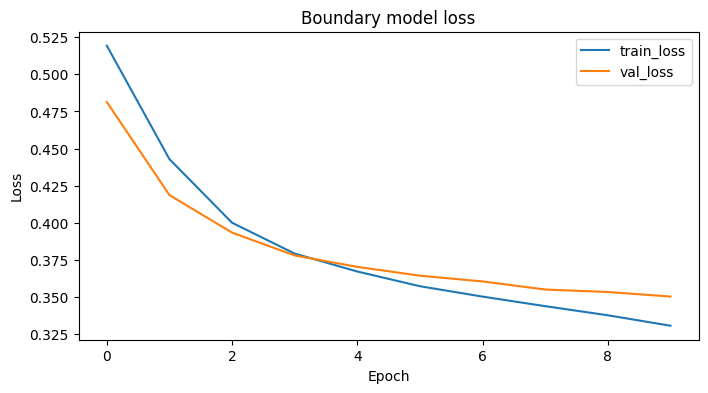

In [90]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Boundary model loss")
plt.legend()
plt.show()

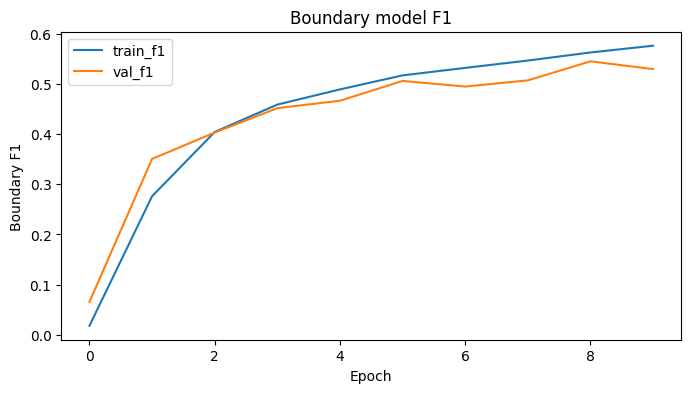

In [91]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_f1"], label="train_f1")
plt.plot(history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Boundary F1")
plt.title("Boundary model F1")
plt.legend()
plt.show()

In [92]:
def predict_boundaries_for_word(word, model, char2id, threshold=0.5):
    model.eval()
    ids = torch.tensor([[char2id.get(ch, char2id["[UNK]"]) for ch in word]], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([len(word)], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logits = model(ids, lengths)
        probs = torch.sigmoid(logits)[0, :len(word)].cpu().numpy()

    labels = (probs >= threshold).astype(int).tolist()
    return probs.tolist(), labels

def split_word_by_boundaries(word, boundary_labels):
    tokens = []
    start = 0
    for i, b in enumerate(boundary_labels):
        if b == 1:
            tokens.append(word[start:i+1])
            start = i + 1
    if start < len(word):
        tokens.append(word[start:])
    return tokens

In [93]:
demo_words = ["tokenizator", "international", "technology", "basketball", "marketplace"]

for w in demo_words:
    probs, labels = predict_boundaries_for_word(w, boundary_model, char2id, threshold=BOUNDARY_THRESHOLD)
    parts = split_word_by_boundaries(w, labels)
    print(f"{w:15s} -> {labels} -> {parts}")

tokenizator     -> [0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0] -> ['token', 'i', 'za', 'tor']
international   -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0] -> ['internation', 'al']
technology      -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] -> ['tech', 'nology']
basketball      -> [0, 0, 1, 0, 0, 1, 0, 0, 0, 0] -> ['bas', 'ket', 'ball']
marketplace     -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0] -> ['market', 'place']


## 7. Tokenization examples

I compare how the three tokenizers segment the same text:

- BPE
- WordPiece
- Neural tokenizer

For the neural tokenizer:
- punctuation is preserved as separate tokens
- alphabetic words are segmented using the BiLSTM boundary predictor

In [94]:
TEXT_TOKEN_PATTERN = re.compile(r"[a-z]+|\d+|[^\w\s]")

def neural_tokenize_text(text, model, char2id, threshold=0.5):
    text = text.lower()
    units = TEXT_TOKEN_PATTERN.findall(text)

    final_tokens = []
    for unit in units:
        if re.fullmatch(r"[a-z]+", unit):
            _, labels = predict_boundaries_for_word(unit, model, char2id, threshold=threshold)
            pieces = split_word_by_boundaries(unit, labels)
            final_tokens.extend(pieces)
        else:
            final_tokens.append(unit)
    return final_tokens

In [95]:
example_sentences = [
    "Apple unveils new technology for mobile devices.",
    "The basketball team won the championship after a dramatic final.",
    "Global markets react to unexpected economic news.",
    "Scientists report a breakthrough in medical research.",
]

for sent in example_sentences:
    print("=" * 80)
    print("TEXT:", sent)
    print("\nBPE:")
    print(bpe_tokenizer.encode(sent.lower()).tokens)
    print("\nWordPiece:")
    print(wp_tokenizer.encode(sent.lower()).tokens)
    print("\nNeural:")
    print(neural_tokenize_text(sent, boundary_model, char2id, threshold=BOUNDARY_THRESHOLD))
    print()

TEXT: Apple unveils new technology for mobile devices.

BPE:
['apple', 'unveils', 'new', 'technology', 'for', 'mobile', 'devices', '.']

WordPiece:
['apple', 'unveils', 'new', 'technology', 'for', 'mobile', 'devices', '.']

Neural:
['app', 'le', 'unve', 'il', 's', 'ne', 'w', 'tech', 'nology', 'for', 'mo', 'bile', 'device', 's', '.']

TEXT: The basketball team won the championship after a dramatic final.

BPE:
['the', 'basketball', 'team', 'won', 'the', 'championship', 'after', 'a', 'dramatic', 'final', '.']

WordPiece:
['the', 'basketball', 'team', 'won', 'the', 'championship', 'after', 'a', 'dram', '##atic', 'final', '.']

Neural:
['the', 'bas', 'ket', 'ball', 'team', 'won', 'the', 'champion', 'ship', 'after', 'a', 'dramatic', 'final', '.']

TEXT: Global markets react to unexpected economic news.

BPE:
['global', 'markets', 're', 'act', 'to', 'u', 'nex', 'pected', 'economic', 'news', '.']

WordPiece:
['global', 'markets', 're', '##act', 'to', 'un', '##ex', '##pe', '##ct', '##ed', 'eco

## 8. Quantitative comparison

I compare the tokenizers using several intrinsic metrics:

1. vocabulary size
2. average number of tokens per text
3. average number of characters per token
4. tokenization speed
5. reconstruction correctness

These metrics help us understand efficiency and segmentation behavior even before the downstream task.

In [96]:
def tokenize_with_bpe(text):
    return bpe_tokenizer.encode(text.lower()).tokens

def tokenize_with_wordpiece(text):
    return wp_tokenizer.encode(text.lower()).tokens

def tokenize_with_neural(text):
    return neural_tokenize_text(text, boundary_model, char2id, threshold=BOUNDARY_THRESHOLD)

In [97]:
def remove_wp_markers(tokens):
    out = []
    for t in tokens:
        out.append(t.replace("##", ""))
    return out

def remove_bpe_markers(tokens):
    return tokens

def reconstruction_from_tokens(tokens):
    return "".join(tokens)

def reference_without_spaces(text):
    return re.sub(r"\s+", "", text.lower())

In [98]:
def evaluate_tokenizer_intrinsic(texts, tokenize_fn, name, cleanup_fn=None):
    token_counts = []
    char_per_token = []
    recon_ok = []
    vocab = Counter()

    start = time.perf_counter()
    all_tokenized = []

    for text in tqdm(texts, desc=f"Tokenizing with {name}"):
        toks = tokenize_fn(text)
        if cleanup_fn is not None:
            toks = cleanup_fn(toks)
        all_tokenized.append(toks)

    elapsed = time.perf_counter() - start

    for text, toks in zip(texts, all_tokenized):
        token_counts.append(len(toks))
        vocab.update(toks)

        if len(toks) > 0:
            char_per_token.extend([len(t) for t in toks])

        recon = reconstruction_from_tokens(toks)
        ref = reference_without_spaces(text)
        recon_ok.append(int(recon == ref))

    return {
        "name": name,
        "vocab_size_on_corpus": len(vocab),
        "avg_tokens_per_text": float(np.mean(token_counts)),
        "avg_chars_per_token": float(np.mean(char_per_token)) if char_per_token else 0.0,
        "tokenization_time_sec": elapsed,
        "reconstruction_accuracy": float(np.mean(recon_ok)),
    }

In [99]:
intrinsic_results = []

intrinsic_results.append(
    evaluate_tokenizer_intrinsic(
        X_test_norm,
        tokenize_with_bpe,
        name="BPE",
        cleanup_fn=remove_bpe_markers,
    )
)

intrinsic_results.append(
    evaluate_tokenizer_intrinsic(
        X_test_norm,
        tokenize_with_wordpiece,
        name="WordPiece",
        cleanup_fn=remove_wp_markers,
    )
)

intrinsic_results.append(
    evaluate_tokenizer_intrinsic(
        X_test_norm,
        tokenize_with_neural,
        name="Neural",
        cleanup_fn=None,
    )
)

intrinsic_df = pd.DataFrame(intrinsic_results)
intrinsic_df

Tokenizing with BPE:   0%|          | 0/5000 [00:00<?, ?it/s]

Tokenizing with WordPiece:   0%|          | 0/5000 [00:00<?, ?it/s]

Tokenizing with Neural:   0%|          | 0/5000 [00:00<?, ?it/s]

,name,vocab_size_on_corpus,avg_tokens_per_text,avg_chars_per_token,tokenization_time_sec,reconstruction_accuracy
0,BPE,3884,60.2314,3.306448,0.663440,1.0000
1,WordPiece,3516,62.3696,3.193094,0.653908,1.0000
2,Neural,10718,64.4780,3.088660,217.750498,0.9988


In [100]:
intrinsic_df["train_time_sec"] = intrinsic_df["name"].map({
    "BPE": timings.get("bpe_train_time_sec", np.nan),
    "WordPiece": timings.get("wordpiece_train_time_sec", np.nan),
    "Neural": timings.get("boundary_train_time_sec", np.nan),
})

intrinsic_df

,name,vocab_size_on_corpus,avg_tokens_per_text,avg_chars_per_token,tokenization_time_sec,reconstruction_accuracy,train_time_sec
0,BPE,3884,60.2314,3.306448,0.663440,1.0000,1.639360
1,WordPiece,3516,62.3696,3.193094,0.653908,1.0000,1.547520
2,Neural,10718,64.4780,3.088660,217.750498,0.9988,19.863264


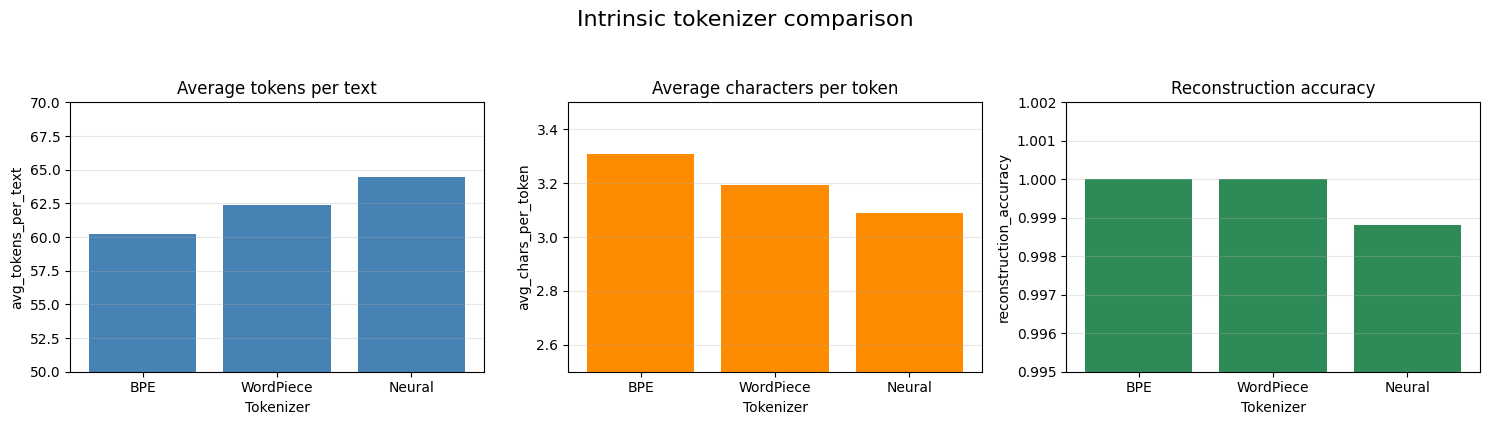

In [105]:
metric_titles = {
    "avg_tokens_per_text": "Average tokens per text",
    "avg_chars_per_token": "Average characters per token",
    "reconstruction_accuracy": "Reconstruction accuracy",
}

colors = {
    "avg_tokens_per_text": "steelblue",
    "avg_chars_per_token": "darkorange",
    "reconstruction_accuracy": "seagreen",
}

y_limits = {
    "avg_tokens_per_text": (50, 70),
    "avg_chars_per_token": (2.5, 3.5),
    "reconstruction_accuracy": (0.995, 1.002),
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4)
)

fig.suptitle("Intrinsic tokenizer comparison", fontsize=16, y=1.05)

for ax, (metric, title) in zip(axes, metric_titles.items()):
    ax.bar(
        intrinsic_df["name"],
        intrinsic_df[metric],
        color=colors[metric]
    )

    ax.set_title(title)
    ax.set_xlabel("Tokenizer")
    ax.set_ylabel(metric)

    ax.set_ylim(y_limits[metric])

    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

These intrinsic results show how the tokenizers differ in segmentation style and computational behavior.

However, intrinsic metrics alone do not tell us whether one tokenizer is better for a real NLP task.

For that reason, the next section includes a downstream text classification experiment.

## 9. Downstream experiment: AG News classification

To compare tokenizers in a real NLP setting, we train the same simple classifier on top of token sequences produced by each tokenizer.

### Goal
Measure how the choice of tokenization affects AG News classification performance.

### Fairness principle
I keep the classifier architecture the same for all tokenizers:
- token embedding
- average pooling with EmbeddingBag
- linear classification head

The only difference between experiments is the tokenizer.

In [106]:
def batch_tokenize_texts(texts, tokenize_fn, desc):
    return [tokenize_fn(t) for t in tqdm(texts, desc=desc)]

train_tokens_bpe = batch_tokenize_texts(X_train_norm, tokenize_with_bpe, "Train BPE")
val_tokens_bpe   = batch_tokenize_texts(X_val_norm, tokenize_with_bpe, "Val BPE")
test_tokens_bpe  = batch_tokenize_texts(X_test_norm, tokenize_with_bpe, "Test BPE")

train_tokens_wp = batch_tokenize_texts(X_train_norm, tokenize_with_wordpiece, "Train WordPiece")
val_tokens_wp   = batch_tokenize_texts(X_val_norm, tokenize_with_wordpiece, "Val WordPiece")
test_tokens_wp  = batch_tokenize_texts(X_test_norm, tokenize_with_wordpiece, "Test WordPiece")

train_tokens_neural = batch_tokenize_texts(X_train_norm, tokenize_with_neural, "Train Neural")
val_tokens_neural   = batch_tokenize_texts(X_val_norm, tokenize_with_neural, "Val Neural")
test_tokens_neural  = batch_tokenize_texts(X_test_norm, tokenize_with_neural, "Test Neural")

Train BPE:   0%|          | 0/30000 [00:00<?, ?it/s]

Val BPE:   0%|          | 0/5000 [00:00<?, ?it/s]

Test BPE:   0%|          | 0/5000 [00:00<?, ?it/s]

Train WordPiece:   0%|          | 0/30000 [00:00<?, ?it/s]

Val WordPiece:   0%|          | 0/5000 [00:00<?, ?it/s]

Test WordPiece:   0%|          | 0/5000 [00:00<?, ?it/s]

Train Neural:   0%|          | 0/30000 [00:00<?, ?it/s]

Val Neural:   0%|          | 0/5000 [00:00<?, ?it/s]

Test Neural:   0%|          | 0/5000 [00:00<?, ?it/s]

In [107]:
def build_token_vocab(tokenized_texts, min_freq=1):
    counter = Counter()
    for toks in tokenized_texts:
        counter.update(toks)

    vocab = {"[PAD]": 0, "[UNK]": 1}
    for tok, freq in counter.items():
        if freq >= min_freq:
            vocab[tok] = len(vocab)
    return vocab

vocab_bpe = build_token_vocab(train_tokens_bpe, min_freq=1)
vocab_wp = build_token_vocab(train_tokens_wp, min_freq=1)
vocab_neural = build_token_vocab(train_tokens_neural, min_freq=1)

len(vocab_bpe), len(vocab_wp), len(vocab_neural)

(3963, 3918, 19803)

In [108]:
class TextClassificationDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab):
        self.tokenized_texts = tokenized_texts
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.tokenized_texts)

    def __getitem__(self, idx):
        toks = self.tokenized_texts[idx]
        ids = [self.vocab.get(t, self.vocab["[UNK]"]) for t in toks]
        label = self.labels[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def cls_collate_fn(batch):
    token_lists, labels = zip(*batch)

    offsets = [0]
    flat_tokens = []

    for seq in token_lists:
        flat_tokens.extend(seq.tolist())
        offsets.append(offsets[-1] + len(seq))

    flat_tokens = torch.tensor(flat_tokens, dtype=torch.long)
    offsets = torch.tensor(offsets[:-1], dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)

    return flat_tokens, offsets, labels

In [109]:
class EmbeddingBagClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, num_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, emb_dim, mode="mean")
        self.fc = nn.Linear(emb_dim, num_classes)

    def forward(self, tokens, offsets):
        x = self.embedding(tokens, offsets)
        logits = self.fc(x)
        return logits

In [110]:
def make_cls_loaders(train_tokens, val_tokens, test_tokens, vocab):
    train_ds = TextClassificationDataset(train_tokens, y_train, vocab)
    val_ds   = TextClassificationDataset(val_tokens, y_val, vocab)
    test_ds  = TextClassificationDataset(test_tokens, y_test, vocab)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TEXTS, shuffle=True, collate_fn=cls_collate_fn)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_TEXTS, shuffle=False, collate_fn=cls_collate_fn)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_TEXTS, shuffle=False, collate_fn=cls_collate_fn)

    return train_loader, val_loader, test_loader

In [111]:
def run_cls_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for tokens, offsets, labels in loader:
        tokens = tokens.to(DEVICE)
        offsets = offsets.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(tokens, offsets)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().tolist())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return total_loss / len(loader), acc, f1

In [112]:
def train_and_evaluate_classifier(name, train_tokens, val_tokens, test_tokens, vocab):
    train_loader, val_loader, test_loader = make_cls_loaders(
        train_tokens, val_tokens, test_tokens, vocab
    )

    model = EmbeddingBagClassifier(
        vocab_size=len(vocab),
        emb_dim=CLS_EMBED_DIM,
        num_classes=4,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR_CLASSIFIER)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

    start = time.perf_counter()

    for epoch in range(NUM_EPOCHS_CLASSIFIER):
        train_loss, train_acc, train_f1 = run_cls_epoch(model, train_loader, optimizer=optimizer)
        val_loss, val_acc, val_f1 = run_cls_epoch(model, val_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"[{name}] Epoch {epoch+1}/{NUM_EPOCHS_CLASSIFIER} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
        )

    elapsed = time.perf_counter() - start

    test_loss, test_acc, test_f1 = run_cls_epoch(model, test_loader, optimizer=None)

    return {
        "name": name,
        "model": model,
        "history": history,
        "train_time_sec": elapsed,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_macro_f1": test_f1,
    }

In [113]:
cls_results = []

cls_results.append(
    train_and_evaluate_classifier(
        "BPE",
        train_tokens_bpe, val_tokens_bpe, test_tokens_bpe,
        vocab_bpe
    )
)

cls_results.append(
    train_and_evaluate_classifier(
        "WordPiece",
        train_tokens_wp, val_tokens_wp, test_tokens_wp,
        vocab_wp
    )
)

cls_results.append(
    train_and_evaluate_classifier(
        "Neural",
        train_tokens_neural, val_tokens_neural, test_tokens_neural,
        vocab_neural
    )
)

[BPE] Epoch 1/5 | train_acc=0.6767 | val_acc=0.8260 | train_f1=0.6735 | val_f1=0.8251
[BPE] Epoch 2/5 | train_acc=0.8612 | val_acc=0.8730 | train_f1=0.8603 | val_f1=0.8726
[BPE] Epoch 3/5 | train_acc=0.8923 | val_acc=0.8826 | train_f1=0.8917 | val_f1=0.8824
[BPE] Epoch 4/5 | train_acc=0.9072 | val_acc=0.8844 | train_f1=0.9067 | val_f1=0.8841
[BPE] Epoch 5/5 | train_acc=0.9159 | val_acc=0.8850 | train_f1=0.9155 | val_f1=0.8847
[WordPiece] Epoch 1/5 | train_acc=0.6785 | val_acc=0.8322 | train_f1=0.6753 | val_f1=0.8312
[WordPiece] Epoch 2/5 | train_acc=0.8620 | val_acc=0.8752 | train_f1=0.8611 | val_f1=0.8747
[WordPiece] Epoch 3/5 | train_acc=0.8934 | val_acc=0.8842 | train_f1=0.8928 | val_f1=0.8838
[WordPiece] Epoch 4/5 | train_acc=0.9076 | val_acc=0.8910 | train_f1=0.9071 | val_f1=0.8908
[WordPiece] Epoch 5/5 | train_acc=0.9174 | val_acc=0.8914 | train_f1=0.9170 | val_f1=0.8911
[Neural] Epoch 1/5 | train_acc=0.6865 | val_acc=0.8360 | train_f1=0.6859 | val_f1=0.8351
[Neural] Epoch 2/5 | 

In [114]:
cls_summary = pd.DataFrame([
    {
        "Tokenizer": r["name"],
        "Classifier train time (sec)": r["train_time_sec"],
        "Test loss": r["test_loss"],
        "Test accuracy": r["test_acc"],
        "Test macro F1": r["test_macro_f1"],
    }
    for r in cls_results
])

cls_summary

,Tokenizer,Classifier train time (sec),Test loss,Test accuracy,Test macro F1
0,BPE,8.273660,0.367599,0.8788,0.877906
1,WordPiece,8.042798,0.357835,0.8838,0.882821
2,Neural,9.136472,0.347436,0.8840,0.883226


In [115]:
cls_summary = pd.DataFrame([
    {
        "Tokenizer": r["name"],
        "Classifier train time (sec)": r["train_time_sec"],
        "Test loss": r["test_loss"],
        "Test accuracy": r["test_acc"],
        "Test macro F1": r["test_macro_f1"],
    }
    for r in cls_results
])

cls_summary

,Tokenizer,Classifier train time (sec),Test loss,Test accuracy,Test macro F1
0,BPE,8.273660,0.367599,0.8788,0.877906
1,WordPiece,8.042798,0.357835,0.8838,0.882821
2,Neural,9.136472,0.347436,0.8840,0.883226


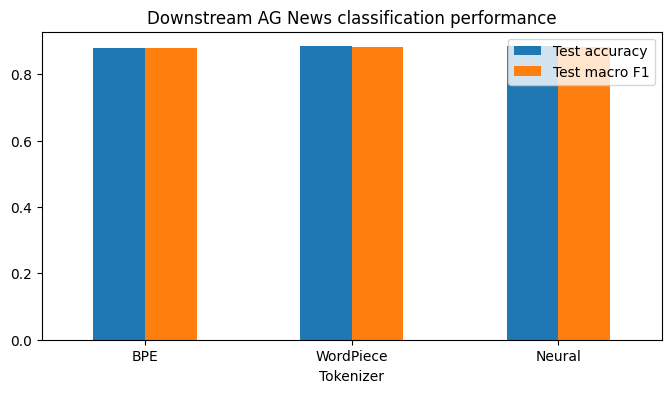

In [116]:
cls_summary.set_index("Tokenizer")[["Test accuracy", "Test macro F1"]].plot(
    kind="bar",
    figsize=(8, 4),
    rot=0,
    title="Downstream AG News classification performance"
)
plt.show()

This section provides the most practical comparison.

Even if a tokenizer looks good intrinsically, it may still be worse for classification.
Conversely, a tokenizer that produces less intuitive subwords may still work well in a downstream model.

That is why both intrinsic and extrinsic evaluation are important.

## 10. Final summary table
This final table combines intrinsic and downstream metrics in one place.

In [117]:
final_summary = intrinsic_df.merge(
    cls_summary,
    left_on="name",
    right_on="Tokenizer",
    how="left"
).drop(columns=["Tokenizer"])

final_summary

,name,vocab_size_on_corpus,avg_tokens_per_text,avg_chars_per_token,tokenization_time_sec,reconstruction_accuracy,train_time_sec,Classifier train time (sec),Test loss,Test accuracy,Test macro F1
0,BPE,3884,60.2314,3.306448,0.663440,1.0000,1.639360,8.273660,0.367599,0.8788,0.877906
1,WordPiece,3516,62.3696,3.193094,0.653908,1.0000,1.547520,8.042798,0.357835,0.8838,0.882821
2,Neural,10718,64.4780,3.088660,217.750498,0.9988,19.863264,9.136472,0.347436,0.8840,0.883226


In [118]:
os.makedirs("outputs", exist_ok=True)

intrinsic_df.to_csv("outputs/intrinsic_results.csv", index=False)
cls_summary.to_csv("outputs/classification_results.csv", index=False)
final_summary.to_csv("outputs/final_summary.csv", index=False)

with open("outputs/timings.json", "w", encoding="utf-8") as f:
    json.dump(timings, f, indent=2)

print("Saved results to outputs/")

Saved results to outputs/
